## **Projektgruppe 13 | Modellierung von Energiesystemen**

###  Mitglieder

| Name | Kürzel | Matrikelnummer |
| :---: | :---: | :---: |
| Abdulmalek Alhaj Malek | aalhajma | 11136361 |
| Anne Kölkes | akoelkes | 11505745 |
| Felix Paul Schneegans | fschneeg | 11145145 |
| Joseph Haddad | jhaddad | 11221931 |
| Julian Lemmerz | jlemmerz | 11146171 |



## **Inhalt**

- Projektvorstellung
    - Fragestellung
    - Energiesystem
- Simulation
    - Lastganganalyse
    - Parameter; Komponenten & Constraints implementieren
    - Blackout Analyse
    - Energiesystem Ist-Zustand: PyPSA-Netzwerk aufbauen & lösen
    - Auswertung Dieselaggregat & Notstrom
    - Aufbau Ausbau-Zustand:  PyPSA-Netzwerk aufbauen & lösen
- Auswertung
    - ...
    

## **Projektvorstellung**

### Bibliotheken

In [42]:
import matplotlib.pyplot as plt
from IPython.display import Image , display
import pypsa as ps
import pandas as pd
import numpy as np
import xarray as xr
import linopy
import gurobipy
from linopy.solvers import Gurobi

### Fragestellung

Kann die unterbrechungsfreie **Stromversorgung (USV) eines Krankenhauses** auf Basis von **Photovoltaik und Batteriespeicher** genauso oder **wirtschaftlich besser** umgesetzt werden, unter Zuhilfenahme verschiedener Business Cases, im Vergleich zu herkömmlicher USV? 


### Systemskizze

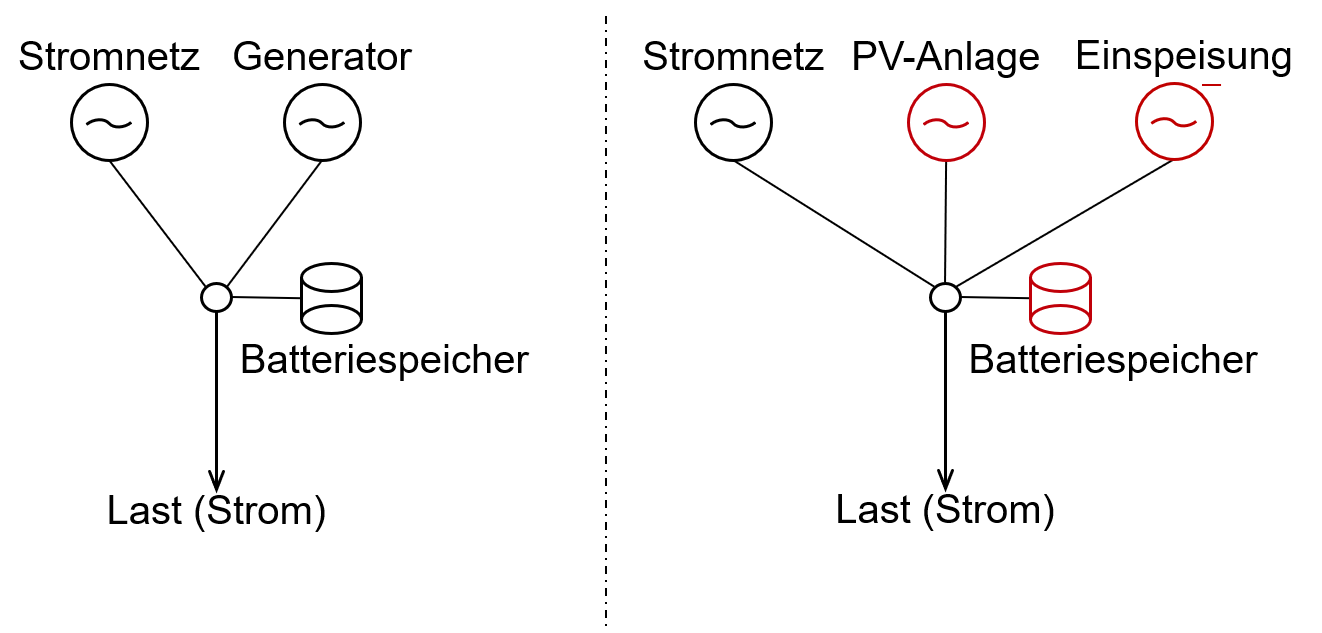

In [2]:
display(Image(filename="Dateien/Abbildungen/Energiesystem - V1.PNG"))
# Batteriespeicher sollen im herkömmlichen Energiesystem raus.
# Da PyPSA Energiesysteme auf einer Zeitskala von 15 Minuten optimiert, lohnt es sich nicht, 
# die kleine USV-Starterbatterie (Überbrückungszeit von wenigen Minuten) explizit zu modellieren. 
# Sie wirkt sich auf dieser Zeitskala kaum aus.

### Das Krankenhaus

Im Rahmen des Forschungsprojektes *"Hybrider Energiespeicher Krankenhaus"* hat das *Fraunhofer-Institut UMSICHT* den thermischen und elektrischen Lastgang eines Krankenhauses aufgezeichnet. Für den Rahmen dieser Untersuchung hat das Institut die Daten großzügiger Weise zur Verfügung gestellt.

Aus dem anhängenden *Abschlussbericht: Hybrider Energiespeicher Krankenhaus* geht allerdings nicht das konkrete Krankenhaus hervor. Eckdaten sind allerdings bekannt:

- 500 Betten
- 14 Fachabteilungen

## **Simulation**

### Import der Zeitreihen/Last-/Verbrauchsprofile

In [3]:
# Import Stromlastprofil des Krankenhauses
hospital_load_profile = pd.read_csv('Dateien/Stromlastgang_Krankenhaus.csv', sep=';', decimal=",")
hospital_power_demand = hospital_load_profile['kW'] # in kW pro 15 min
hospital_electricity_consumption = hospital_load_profile['kWh'] # in kWh pro 15 min

### **Lastanalyse**

### Stromlastprofil

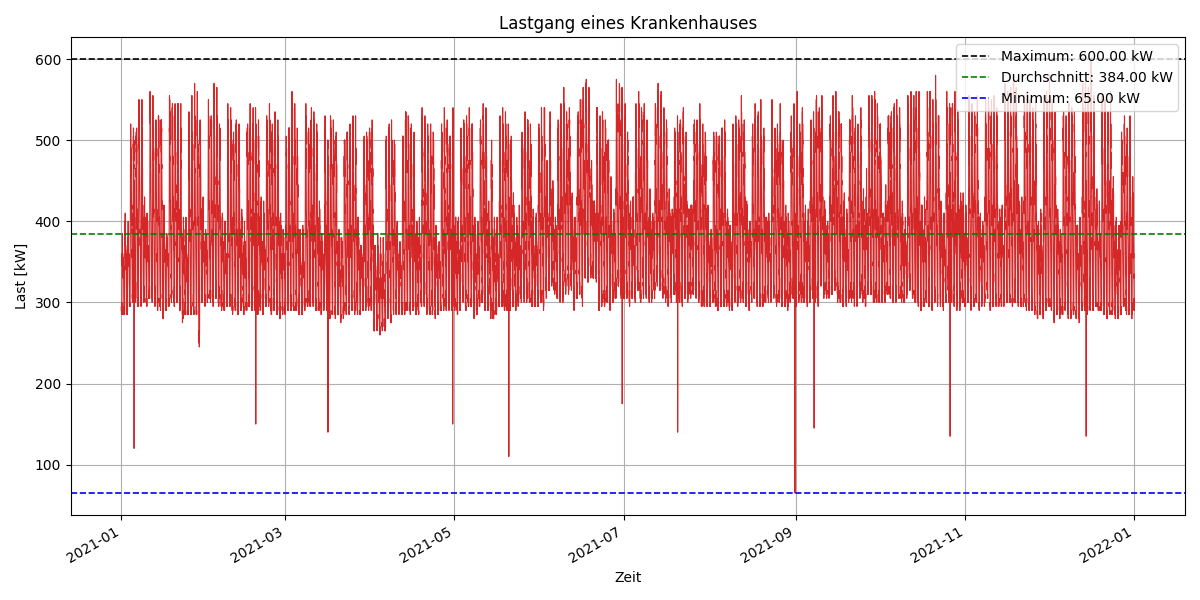

In [4]:
display(Image(filename="Dateien/Abbildungen/Lastgang.png"))

- 15-minütige Auflösung
- Vollständiger Lastgang über ein Jahr (2021) mit 35.040 Werten
- Arbeitswochen (Werktage + Wochenende)

### Heatmap

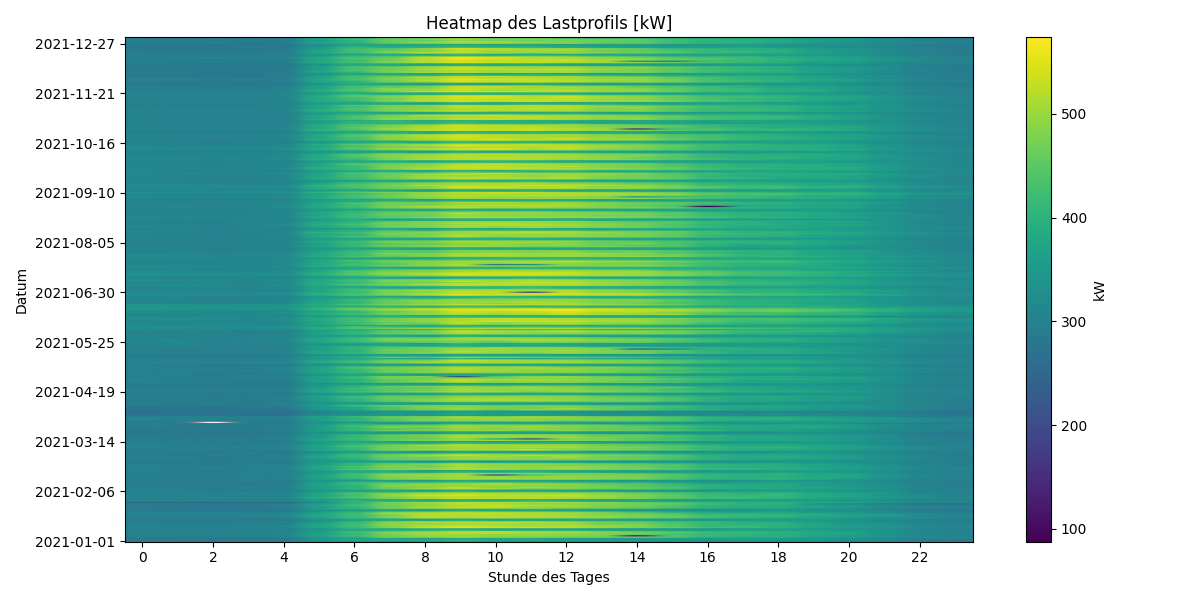

In [5]:
display(Image(filename="Dateien/Abbildungen/Heatmap.png"))

- **Raumwärme** nicht an elektrische Last gekoppelt (Versorgung über Fernwärme)
- mutmaßlich **Kälteanlagen** generieren über die Sommermonate Last
- mutmaßlich **Beleuchtung** zwischen 4:30 Uhr - 21:30 Uhr
- mutmaßlich **Kernarbeitszeit** zwischen 6:30 Uhr - 15:30 Uhr
- Messfehler im Lastprofil:
    - etwa zum 15.04.2021 fehlen rd. 4 Tage
    - innerhalb einiger Tage fehlen wenige Stunden (11 Messfehler)
- Lastprofil liegt ohne Zeitverschiebung vor

### **Parameter**


### Energiepreise


0        0.212903
1        0.212903
2        0.212903
3        0.212903
4        0.212796
           ...   
35035    0.223565
35036    0.213403
35037    0.213403
35038    0.213403
35039    0.213403
Name: Strompreis [Euro/kWh], Length: 35040, dtype: float64


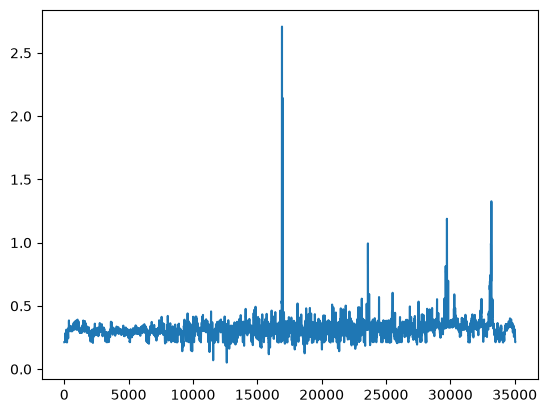

In [6]:
dynamic_tarrifs = True

df_electricity_price = pd.read_csv(r'Dateien\data_PyPSA_1.csv', # Strompreise einlesen. Für statisch & dynamisch genutzt
                                     sep=',',
                                     decimal = '.').iloc[:,0]
df_electricity_price = df_electricity_price.drop(df_electricity_price.index[1416:1440]) # Schalttag entfernen

if dynamic_tarrifs == False:
     electricity_price = df_electricity_price.mean()   # Damit  die Datenbasis identisch bleibt, wird hier der Mittelwert des zugrundeliegenden dynamischen Strompreises angegeben
     print(electricity_price)
else:
     electricity_price = df_electricity_price
     electricity_price = electricity_price.repeat(4)    # Stundenwerte auf Viertelstunden erweitern
     electricity_price = electricity_price.reset_index(drop=True)    # alten Index verwerfen
     print(electricity_price)
     plt.plot(electricity_price)
     plt.show

capacity_charge = 21.41  # €/kW/Jahrleistungspreis pro kW Quelle: RheinNetz
infeed_revenue = 0.08 # €/kWh Einspeisevergütung Quelle: bdew
fuel_price = 1.712 # €/l Dieselpreis

#### Energiepreis Regelenergie Primär

In [7]:
fcr_data = pd.read_csv(
    r'Dateien\RESULT_OVERVIEW_CAPACITY_MARKET_FCR_2021-01-01_2021-12-31.csv',
    sep=';',
    decimal=','
)

fcr_data = fcr_data[
    fcr_data["TENDER_NUMBER"] == 1
].copy()

# DATE_FROM in echtes Datum umwandeln
fcr_data["DATE_FROM"] = pd.to_datetime(
    fcr_data["DATE_FROM"],
    format="%d.%m.%Y"
)

missing_day = fcr_data[
    fcr_data["DATE_FROM"] == pd.Timestamp("2021-10-02")
].copy()

missing_day["DATE_FROM"] = pd.Timestamp("2021-10-03")

missing_date = pd.Timestamp("2021-10-03")

if missing_date not in fcr_data["DATE_FROM"].values:

    missing_day = fcr_data[
        fcr_data["DATE_FROM"] == pd.Timestamp("2021-10-02")
    ].copy()

    missing_day["DATE_FROM"] = missing_date

    fcr_data = pd.concat(
        [fcr_data, missing_day],
        ignore_index=True
    )

fcr_data = fcr_data.sort_values(
    ["DATE_FROM", "PRODUCTNAME"]
).reset_index(drop=True)

print(len(fcr_data))

fcr_price_15min = np.repeat(
    fcr_data["CROSSBORDER_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"].to_numpy(),
    16
)

print(len(fcr_price_15min)) 

fcr_data = fcr_data.rename(columns={
    "CROSSBORDER_SETTLEMENTCAPACITY_PRICE_[EUR/MW]": "settlement_cap_price" #€/MW
})

2190
35040


### Stromnetz

In [8]:
grid_import_limit = 800 # kW Spitzenlast (600kW)+ 200kW

### Diesel-Generator

In [9]:
diesel_power = 715 # Leistung in kVA
load_factor = 0.8 # Leistungsfaktor
diesel_rated_power = 572 # Nennleistung in kW  studylib.net/doc/28391870/99-2019-health-care-facilities-code-handbook    studylib.net/doc/28037269/nfpa-99-2024-health-care-facilities-code   hospitalinspections.org/report-detail/LN1R21
min_load_factor = 0.3 # Minimale Auslastung
min_diesel_power = 172 # Mindestbetriebspunkt in kW
fuel_consumption_full = 146.7 # Verbrauch Volllast in l/h
fuel_consumption_idle_75 = 110 # Verbrauch Teillast (75%) in l/h
fuel_consumption_idle_50 = 76.4 # Verbrauch Teillast (50%) in l/h
fuel_tank_capacity_epu = 800 # Tankinhalt in l
fuel_storage = 4225 # Treibstoffvorrat in l
fuel_price = fuel_price # Verweis auf gesammelte Energiepreise-Zelle
capex_diesel = 900 # Investitionskosten in €/kW
opex_diesel = 15444 # Betriebskosten in €/a
lifetime_diesel = 20 # Lebensdauer in a
diesel_cost_per_hour = fuel_consumption_full*fuel_price  # Dieselkosten in €/h bei Vollastbetrieb
diesel_marginal_cost = diesel_cost_per_hour / diesel_rated_power  # Dieselkosten in €/kWh 

### PV-Anlage

In [10]:
infeed_revenue = infeed_revenue # Verweis auf gesammelte Energiepreise-Zelle
 
# Import PV-Erzeugung und weitere Zeitreihen
 
pv_peak_power = 2500      # kWp installierte PV-Leistung
pv_capex = 1250           # €/kWp Investitionskosten
pv_opex = 0.015           # Anteil CAPEX pro Jahr (Betriebskosten, 1,5 %/a)
pv_lifetime = 25          # a Lebensdauer
degradation_rate = 0.005  # -/a jährliche Degradation
 
# Jährliche Fixkosten pro kWp = lineare Abschreibung + Betriebskosten (Stil wie Diesel)
pv_capital_cost = pv_capex / pv_lifetime + pv_opex * pv_capex   # = 68,75 €/kWp/a
 
# --- PV-Erzeugungsprofil (PVGIS Köln, 2021, Referenz 1 kWp) ---
pv_raw = pd.read_csv('Dateien/PV_PyPSA_Erzeugung_h.csv', sep=';', decimal=',')
 
pv_erzeugung = pv_raw['PV Erzeugung [kW]'].to_numpy()   # schon numerisch, da decimal=','
 
# stündlich (8760) -> 15-min (35040): jeden Wert 4x
pv_erzeugung = np.repeat(pv_erzeugung, 4)

### Batteriespeicher

In [11]:
# Ein 4h-System bestimmt das Verhältnis von Kapazität zu Leistung
max_hours = 4.0

# Diskrete Speichergrößen mit linear interpolierten Kosten

def add_discrete_bess_sizes(n, snapshots):
    
    m = n.model
    
# Dynamisch den Namen der Dimension herausfinden (z.B. 'StorageUnit-ext' oder 'StorageUnit')
    p_nom_var = m.variables['StorageUnit-p_nom']
    dim_name = p_nom_var.dims[0]
    p_nom_bess = p_nom_var.sel({dim_name: 'Batteriespeicher'})
    
# Definieren der möglichen Speichergrößen in kWh (500 bis 12000 in 500er Schritten)
    sizes_kwh = np.arange(500, 12500, 500)
    sizes_index = pd.Index(sizes_kwh, name='storage_size')
    
# Interpolation der spezifischen Kosten in €/kWh basierend auf Ihren Stützstellen
    xp = [1000, 3500, 7000, 10000]
    fp = [360, 310, 285, 273]
    
# np.interp interpoliert linear zwischen den Punkten
    spec_costs = np.interp(sizes_kwh, xp, fp)
    
# Binärvariablen für jede der möglichen Größen erstellen
    bin_vars = m.add_variables(binary=True, coords=[sizes_index], name='storage_selector')
    
# Constraint 1: Es darf maximal EINE Speichergröße ausgewählt werden
    m.add_constraints(bin_vars.sum() == 1, name='select_at_most_one_size')
    
# Constraint 2: Die Kapazität im PyPSA-Netzwerk (p_nom in kW) an die Auswahl knüpfen
    power_kw = sizes_kwh / (max_hours)
    power_da = xr.DataArray(power_kw, coords=[sizes_index])
    m.add_constraints(p_nom_bess == (bin_vars * power_da).sum(), name='link_size_to_pnom')

# Constraint 3: Energie vorhalten für möglichen Blackout
    soc_var = m.variables["StorageUnit-state_of_charge"]

    soc_storage_dim = [
        dim for dim in soc_var.dims
        if dim != "snapshot"
    ][0]

    # Komplette SOC-Zeitreihe des Batteriespeichers auswählen
    soc_bess = soc_var.sel({
        soc_storage_dim: "Batteriespeicher"
    })

    # Dauer der Wiederaufladephase nach dem Blackout
    recharge_duration_h = 24

    # Anzahl der Zeitschritte der Wiederaufladephase
    recharge_steps = recharge_duration_h * steps_per_hour

    # Standard:
    # Außerhalb von Blackout und Wiederaufladephase
    # muss die vollständige Blackoutreserve vorhanden sein
    min_soc = np.full(
        len(n.snapshots),
        blackout_reserve_kwh,
        dtype=float
    )

    # Ende des Blackouts
    blackout_end = blackout_start + blackout_steps

    # Während des Blackouts darf die gesamte Reserve verwendet werden
    min_soc[
        blackout_start:blackout_end
    ] = 0.0

    # Ende der Wiederaufladephase
    recharge_end = min(
        blackout_end + recharge_steps,
        len(n.snapshots)
    )

    # Tatsächlich vorhandene Zeitschritte für die Wiederaufladung
    n_recharge_steps = recharge_end - blackout_end

    # Nach dem Blackout steigt die vorgeschriebene Mindestenergie
    # linear wieder bis auf die vollständige Blackoutreserve an
    if n_recharge_steps > 0:
        min_soc[
            blackout_end:recharge_end
        ] = np.linspace(
            0,
            blackout_reserve_kwh,
            n_recharge_steps + 1
        )[1:]

    # NumPy-Zeitreihe in xarray umwandeln
    min_soc_da = xr.DataArray(
        min_soc,
        coords={"snapshot": n.snapshots},
        dims=["snapshot"]
    )

    # Harte Randbedingung:
    # tatsächlicher Energieinhalt >= geforderte Mindestreserve
    m.add_constraints(
        soc_bess >= min_soc_da,
        name="BESS_blackout_energy_reserve"
    )

# alt
#    snapshot_before_blackout = (n.snapshots[blackout_start - 1])
#
#   soc_before_blackout = soc_var.sel({
#        soc_storage_dim: "Batteriespeicher",
#        "snapshot": snapshot_before_blackout
#    })
#
#    m.add_constraints(soc_before_blackout==p_nom_bess * max_hours,name="BESS_full_before_blackout")
    
# Zielfunktion: Gesamtkosten (Investition * Annuität) der gewählten Größe hinzufügen
    interest_rate = 0.02
    lifespan = 15
    annuity_factor = ((1+interest_rate)**lifespan)*interest_rate / (((1+interest_rate)**lifespan)-1)
    total_capex_annuity = sizes_kwh * spec_costs * annuity_factor
    costs_da = xr.DataArray(total_capex_annuity, coords=[sizes_index])
    m.objective += (bin_vars * costs_da).sum()

#bess_capacity_init = 3500 #kWh BESS Kapazität Quelle: NACHTRAGEN
#bess_capacity = 10000 #kWh BESS Kapazität --> Auszulegen
#bess_power_init = 875 #kW BESS Leistung Quelle: NACHTRAGEN
#bess_soc_min = 0.1 #% BESS SOC min Quelle: NACHTRAGEN
#bess_soc_max = 1 #% BESS SOC max Quelle: NACHTRAGEN
#bess_roundtrip_eff = 0.85 # BESS Roundtrip-Wirkungsgrad Quelle: NACHTRAGEN 
#bess_charge_eff = 0.922 # BESS Ladewirkungsgrad Quelle: errechnet aus roundtrip_eff und discharg_eff
#bess_discharg_eff = 0.922 # BESS Entladewirkungsgrad Quelle: errechnet aus roundtrip_eff und charge_eff
#bess_initial_soc = 0.5 #% BESS SOC bei Simulationss start Quelle: NACHTRAGEN
#bess_max_hours = 1
#capex_bess_init = 310 #€/kWh
#bess_capex = capex_bess_init * (bess_capacity_init/bess_capacity)**0.12 #€ BESS Investitionskosten Quelle: NACHTRAGEN

# nicht mehr benötigt?
# zinssatz = 0.02 # Zinsen in pu
# lebensdauer_batterie = 20 # Jahre
# roundtrip_eff_batterie = 0.95 # Wikrungsgrad in pu
# invest_kosten_batterie = 750 #in Euro 
# annuitaet_batterie = invest_kosten_batterie*((1+zinssatz)**lebensdauer_batterie)*zinssatz/((1+zinssatz)**lebensdauer_batterie-1)
#n_up.add('StorageUnit',
#              name = 'battery',
#              bus = 'electricity',
#              p_nom_extendable = True,
#              capital_cost = bess_capex,
#              max_hours = bess_max_hours,
#              efficiency_store = bess_charge_eff,
#              efficiency_dispatch = bess_discharg_eff
#             )

### Blackout-Parameter

In [12]:
blackout = True 
critical_load_share = 0.8 # dke.de/de/normen-standards/dokument?id=7020397&type=dke%7Cdokument&     nature.com/articles/s41598-026-56638-8
# Für die Simulation wird angenommen, dass im Falle eines Netzausfalls 80 % des elektrischen Lastprofils als kritische Last aufrechterhalten werden müssen. Die DIN VDE 0100-710 fordert eine Sicherheitsstromversorgung für sicherheitsrelevante Verbraucher in medizinisch genutzten Bereichen, gibt jedoch keinen pauschalen prozentualen Anteil an der Gesamtlast vor. Der kritische Lastanteil wird daher als Modellannahme festgelegt. Vergleichbare wissenschaftliche Untersuchungen von Krankenhaus-Microgrids verwenden ebenfalls prozentuale kritische Lastanteile, beispielsweise 70 %
critical_load = hospital_power_demand * critical_load_share  # kritische Last
blackout_frequency = 1  # Blackouts pro Jahr
blackout_duration_h = 24  # 24-stündiger Blackout
steps_per_hour = 4  # 15-min-Auflösung
blackout_steps = blackout_duration_h * steps_per_hour  # Blackout-Zeitschritte

### **Energiesysteme: Ist-Zustand & Upgrade**

### Tag mit höchstem Energieverbrauch

In [13]:
# Anzahl der Zeitschritte pro Tag
steps_per_day = 96

# Tagesnummer erzeugen
hospital_load_profile["Tag"] = hospital_load_profile.index // steps_per_day

# Energie pro Tag aufsummieren
daily_energy = hospital_load_profile.groupby("Tag")["kWh"].sum()

# Tag mit maximalem Energieverbrauch
max_day = daily_energy.idxmax()
max_energy = daily_energy.max()
blackout_reserve_kwh = max_energy * critical_load_share


print(f"Tag mit höchstem Energieverbrauch: {max_day}")
hospital_load_profile["Ab-Datum"] = pd.to_datetime(hospital_load_profile["Ab-Datum"],format="%d.%m.%Y")
datum = (hospital_load_profile[hospital_load_profile["Tag"] == max_day].iloc[0]["Ab-Datum"])
print(f"Datum: {datum.strftime('%d.%m.%Y')}")
print(f"Energieverbrauch: {max_energy:,.0f} kWh".replace(",", "."))
if blackout_reserve_kwh is not None:
    print(f'Benötigte Blackout Reserve auf {blackout_reserve_kwh:,.0f} kWh gesetzt'.replace(',','.') )

Tag mit höchstem Energieverbrauch: 167
Datum: 17.06.2021
Energieverbrauch: 10.806 kWh
Benötigte Blackout Reserve auf 8.645 kWh gesetzt


### Maximale rollierende 24-stündige Energie

In [14]:
# Anzahl der Zeitschritte für 24 Stunden
window = 96

# Rollierende 24-h-Energiesumme
rolling_energy = (
    hospital_load_profile["kWh"]
    .rolling(window=window)
    .sum()
)

# Maximale 24-h-Energie
max_energy = rolling_energy.max()

# Endindex des Fensters
end_idx_24h_energy = rolling_energy.idxmax()

# Startindex des Fensters
start_idx_24h_energy = end_idx_24h_energy - window + 1


print(f"Start-Zeitschritt: {start_idx_24h_energy}")
print(f"End-Zeitschritt: {end_idx_24h_energy}")
start_date = hospital_load_profile.loc[start_idx_24h_energy, "Ab-Datum"]
end_date = hospital_load_profile.loc[end_idx_24h_energy, "Ab-Datum"]
start_time = hospital_load_profile.loc[start_idx_24h_energy, "Ab-Zeit"]
end_time = hospital_load_profile.loc[end_idx_24h_energy, "Ab-Zeit"]
print("Beginn:",start_date.strftime("%d.%m.%Y"), start_time)
print("Ende:",end_date.strftime("%d.%m.%Y"), end_time)
print(f"Maximale rollierende 24-h-Energie: {max_energy:,.0f} kWh".replace(",", "."))

energy_day167 = daily_energy.loc[167]

if max_energy > energy_day167:
    print("Es existieren 24 aufeinanderfolgende Stunden mit höherem Energieverbrauch als Tag 167.")
else:
    print("Tag 167 besitzt bereits die höchste 24-h-Energie.")

Start-Zeitschritt: 16063
End-Zeitschritt: 16158
Beginn: 17.06.2021 08:45:00
Ende: 18.06.2021 08:30:00
Maximale rollierende 24-h-Energie: 10.858 kWh
Es existieren 24 aufeinanderfolgende Stunden mit höherem Energieverbrauch als Tag 167.


### Tag mit höchster Spitzenlast

In [15]:
# Maximale Leistung je Tag
daily_peak = hospital_load_profile.groupby("Tag")["kW"].max()

# Tag mit der höchsten Spitzenlast
peak_day = daily_peak.idxmax()
peak_power = daily_peak.max()

print(f"Tag mit höchster Spitzenlast: {peak_day}")
datum = (hospital_load_profile[hospital_load_profile["Tag"] == peak_day].iloc[0]["Ab-Datum"])

# Erster Zeitschritt des Peak-Tages
start_idx_max_power = hospital_load_profile[hospital_load_profile["Tag"] == peak_day].index.min()

# Letzter Zeitschritt (24 Stunden)
end_idx_max_power = start_idx_max_power + 96

print("Startzeitschritt:", start_idx_max_power)
print("Endzeitschritt:", end_idx_max_power - 1)

print(f"Datum: {datum.strftime('%d.%m.%Y')}")
print(f"Spitzenlast: {peak_power:.0f} kW")

Tag mit höchster Spitzenlast: 349
Startzeitschritt: 33504
Endzeitschritt: 33599
Datum: 16.12.2021
Spitzenlast: 600 kW


### Blackout-Tage

In [16]:
blackout_start_max_energy = start_idx_24h_energy  # 24 Stunden mit höchstem Energieverbrauch
blackout_start_max_power = start_idx_max_power  # Tag mit höchster Spitzenlast
blackout_start = blackout_start_max_energy  # !!! Variabel: alternativ blackout_start_max_power

### **Ist-Zustand**

In [17]:
# PyPSA-Netzwerk für das herkömmliche Energiesystem
n_is = ps.Network()
n_is.set_snapshots(range(35040)) # 35.040 Zeitschritte für 15-minütige Daten über ein Jahr

c:\Users\Juli\OneDrive - TH Köln\VSC\Masterstudium\Modellierung von Energiesystemen\MoE-Team05\.venv_sim\Lib\site-packages\pypsa\network\io.py:2082: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)


### Blackout-Implementierung

In [18]:
# Netzverfügbarkeit
grid_availability_is = np.ones(len(n_is.snapshots))

# Lastprofil für den Ist-Zustand
load_is = hospital_power_demand.copy()

if blackout:

    # Stromnetz fällt während des Blackouts aus
    grid_availability_is[
        blackout_start : blackout_start + blackout_steps
    ] = 0

    # Während des Blackouts bleibt nur die kritische Last bestehen
    load_is.iloc[
        blackout_start : blackout_start + blackout_steps
    ] = critical_load.iloc[
        blackout_start : blackout_start + blackout_steps
    ]

### Monatlicher Funktionstest mit mindestens 80 % Last

In [19]:
# test_load_factor = 0,8 bis 1  buffl.co/en/community/c/656342c3a807ecc023c9cbac

steps_per_hour = 4
steps_per_day = 96

test_days = [4, 45, 74, 103, 136, 164, 194, 227, 256, 286, 318, 347]
test_mask = np.zeros(len(n_is.snapshots), dtype=bool)
for day in test_days:
    start = day * steps_per_day + 12*steps_per_hour  # Test beginnt um 12:00 Uhr
    test_mask[start:start+steps_per_hour] = True   # 1 Stunde = 4 Viertelstunden

# Während der Teststunden kein Netzstrom
grid_availability_is[test_mask] = 0

# Geänderte Netzverfügbarkeit an PyPSA übergeben
n_is.generators_t.p_max_pu["grid_power"] = grid_availability_is

### Dieselgenerator-Verfügbarkeit

In [20]:
# Maske für Blackout
blackout_mask = np.zeros(len(n_is.snapshots), dtype=bool)

blackout_mask[
    blackout_start:blackout_start + blackout_steps
] = True

# Dieselgeneratorverfügbarkeit
diesel_availability = np.zeros(len(n_is.snapshots))

# Dieselgenerator während Blackout verfügbar
diesel_availability[blackout_mask] = 1

# Dieselgenerator während Funktionstests verfügbar
diesel_availability[test_mask] = 1

n_is.generators_t.p_max_pu["diesel_generator"] = diesel_availability

### Aufbau des PyPSA-Netzwerks

In [21]:
#Bus
n_is.add('Bus',
              name = 'electricity'
              )

#Carrier
n_is.add("Carrier",
              name="diesel"
              )

#Load
n_is.add('Load',
              name = 'electrical_load',
              bus = 'electricity',
              p_set = load_is
              )

#Generator
n_is.add('Generator',
              name = 'grid_power',
              bus = 'electricity',
              carrier = 'diesel',
              p_nom = grid_import_limit,
              p_max_pu = grid_availability_is,
              marginal_cost = electricity_price,
              capital_cost = capacity_charge
              )

n_is.add('Generator', 
             name="diesel_generator", 
             bus="electricity", 
             p_nom=diesel_rated_power, 
             p_min_pu=min_load_factor, 
             marginal_cost=diesel_marginal_cost, 
             capital_cost=capex_diesel / lifetime_diesel, 
             committable=True, 
             start_up_cost=80)

### **Auswertung**

In [ ]:
linopy.available_solvers.refresh()
print(list(linopy.available_solvers))
print(gurobipy.gurobi.version())
print(Gurobi.is_available())
print(Gurobi.license_status())

['gurobi', 'highs']
(13, 0, 3)
True
Restricted license - for non-production use only - expires 2027-11-29


INFO:gurobipy:Restricted license - for non-production use only - expires 2027-11-29


LicenseStatus(solver='gurobi', ok=True, message=None)


### Netzwerkoptimierung

In [23]:
n_is.optimize(solver_name="highs")

C:\Users\Juli\AppData\Local\Temp\ipykernel_22256\3815676144.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_is.optimize(solver_name="highs")
Index(['electricity'], dtype='object', name='name')
Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       35030, 35031, 35032, 35033, 35034, 35035, 35036, 35037, 35038, 35039],
      dtype='int64', name='snapshot', length=34896)
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 196.96it/s]
INFO:linopy.io: Writing time: 0.3s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 175200 primals, 385440 duals
Objective: 4.13e+0

('ok', 'optimal')

### Monatlicher Funktionstest mit mindestens 80 % Last

In [24]:
diesel_power_test = n_is.generators_t.p["diesel_generator"][test_mask]
diesel_load_share_test_percent = (diesel_power_test / diesel_rated_power * 100)
within_range = (
    (diesel_load_share_test_percent >= 80) &
    (diesel_load_share_test_percent <= 100)
)
test_check = pd.DataFrame({
    "Krankenhauslast [kW]":
        load_is.iloc[test_mask].to_numpy(),

    "Netz [kW]":
        n_is.generators_t.p["grid_power"].iloc[test_mask].to_numpy().round(0).astype(int),

    "Diesel [kW]":
        n_is.generators_t.p["diesel_generator"].iloc[test_mask].to_numpy().round(0).astype(int),

    "Diesel-Auslastung [%]":
        (n_is.generators_t.p["diesel_generator"].iloc[test_mask].to_numpy()/ diesel_rated_power * 100).round(0).astype(int)
},
     index=n_is.snapshots[test_mask])

test_check.index.name = "Zeitschritt"

test_check["Netz [kW]"] = (
    test_check["Netz [kW]"]
    .where(test_check["Netz [kW]"].abs() > 1e-6, 0)
)
display(test_check.round(1))

print("Alle Werte der Diesel-Auslastung zwischen 80 % und 100 %:", within_range.all())

,Krankenhauslast [kW],Netz [kW],Diesel [kW],Diesel-Auslastung [%]
Zeitschritt,,,,
432,485,0,485,85
433,485,0,485,85
434,475,0,475,83
435,485,0,485,85
4368,515,0,515,90
4369,520,0,520,91
4370,480,0,480,84
4371,475,0,475,83
7152,480,0,480,84


Alle Werte der Diesel-Auslastung zwischen 80 % und 100 %: True


### Kraftstoffverbrauch nach der Optimierung

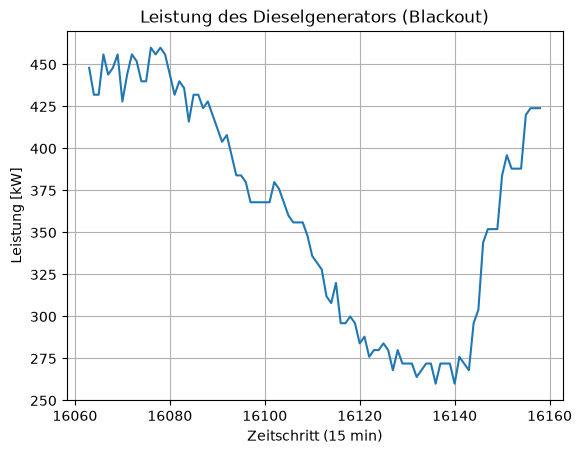

,Leistung des Dieselgenerators (Blackout) [kW]
snapshot,
16063,448
16064,432
16065,432
16066,456
16067,444
...,...
16154,388
16155,420
16156,424


In [25]:
diesel_generator_power_output = n_is.generators_t.p["diesel_generator"]
plt.plot(diesel_generator_power_output[blackout_start : blackout_start + blackout_steps])
plt.title("Leistung des Dieselgenerators (Blackout)")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")
plt.grid(True)
plt.show()
diesel_blackout_df = diesel_generator_power_output[
    blackout_start : blackout_start + blackout_steps
    ].to_frame(name="Leistung des Dieselgenerators (Blackout) [kW]")
diesel_blackout_df.astype(int)

### Lineare Interpolation der Verbrauchskennlinie

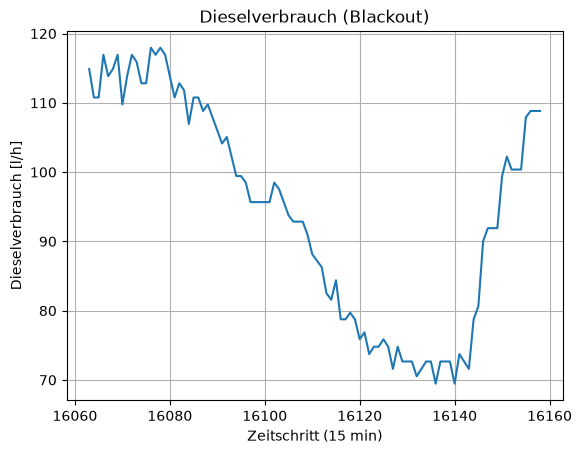

,Dieselverbrauch [l/h]
Zeitschritt,
16063,115
16064,111
16065,111
16066,117
16067,114
...,...
16154,100
16155,108
16156,109


In [26]:
def diesel_consumption(power):  # Dieselverbrauch in l/h

    load = power / diesel_rated_power  # Anteil der Nennleistung

    if load <= 0:  # Generator aus → kein Kraftstoffverbrauch
        return 0

    elif load <= 0.5:  # Bereich zwischen 0% und 50% Teillast
        return fuel_consumption_idle_50 * load / 0.5

    elif load <= 0.75:  # Bereich zwischen 50% und 75% Teillast
        return fuel_consumption_idle_50 + \
               (fuel_consumption_idle_75-fuel_consumption_idle_50) * \
               (load-0.5)/0.25

    else:  # Bereich über 75%
        return fuel_consumption_idle_75 + \
               (fuel_consumption_full-fuel_consumption_idle_75) * \
               (load-0.75)/0.25

fuel = diesel_generator_power_output.apply(diesel_consumption)  # Zeitreihe mit Dieselverbrauch l/h
plt.plot(fuel[blackout_start : blackout_start + blackout_steps])
plt.title("Dieselverbrauch (Blackout)")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Dieselverbrauch [l/h]")
plt.grid(True)
plt.show()
fuel_df = fuel.to_frame(name="Dieselverbrauch [l/h]")
fuel_df[blackout_start : blackout_start + blackout_steps]
fuel_df.index.name = "Zeitschritt"
fuel_df[blackout_start : blackout_start + blackout_steps].round(0).astype(int)

#### Gesamtdieselverbrauch im Simulationsjahr 

In [27]:
# Tatsächliche Dieselgeneratorleistung aus PyPSA [kW]
diesel_power_output = n_is.generators_t.p["diesel_generator"]

# Kraftstoffverbrauch für jeden Zeitschritt [l/h]
fuel = diesel_power_output.apply(diesel_consumption)

# Dieselverbrauch (Blackout)
fuel_blackout = (fuel.iloc[blackout_start:blackout_start + blackout_steps] * 0.25).sum()
formatted_fuel_blackout = f"{fuel_blackout:,.0f}".replace(",", ".")
print("Dieselverbrauch (Blackout):",formatted_fuel_blackout,"l")

# Dieselverbrauch (Funktionstests)
fuel_test_total = (fuel.iloc[test_mask] * 0.25).sum()
formatted_fuel_test = f"{fuel_test_total:,.0f}".replace(",", ".")
print("Dieselverbrauch (Funktionstests):",formatted_fuel_test,"l")

# Gesamtdieselverbrauch
fuel_total = (fuel * 0.25).sum()
formatted_fuel_total = f"{fuel_total:,.0f}".replace(",", ".")
print("Gesamtdieselverbrauch:",formatted_fuel_total,"l")

Dieselverbrauch (Blackout): 2.261 l
Dieselverbrauch (Funktionstests): 1.518 l
Gesamtdieselverbrauch: 3.779 l


#### Gesamtdieselkosten im Simulationsjahr 

In [28]:
# Dieselkosten (Blackout)
fuel_cost_blackout = fuel_blackout * fuel_price
formatted_fuel_cost_blackout = (f"{fuel_cost_blackout:,.0f}".replace(",", "."))
print("Dieselkosten (Blackout):",formatted_fuel_cost_blackout,"€")

# Dieselkosten (Funktionstests)
fuel_cost_test = fuel_test_total * fuel_price
formatted_fuel_cost_test = (f"{fuel_cost_test:,.0f}".replace(",", "."))
print("Dieselkosten (Funktionstests):",formatted_fuel_cost_test,"€")

# Gesamtdieselkosten
fuel_cost_total = fuel_total * fuel_price
formatted_fuel_cost_total = (f"{fuel_cost_total:,.0f}".replace(",", "."))
print("Gesamtdieselkosten:",formatted_fuel_cost_total,"€")


Dieselkosten (Blackout): 3.871 €
Dieselkosten (Funktionstests): 2.598 €
Gesamtdieselkosten: 6.470 €


#### Betriebsstunden im Simulationsjahr 

In [29]:
running = diesel_generator_power_output > 0
operating_hours = running.sum() * 0.25
print("Betriebsstunden:", round(operating_hours), "h")

Betriebsstunden: 36 h


#### Anzahl an Starts im Simulationsjahr 

In [30]:
starts = ((running.astype(int).diff()) == 1).sum()
print("Anzahl an Starts:", starts)

Anzahl an Starts: 13


### Ergebnisse des PyPSA-Netzwerks

In [31]:
# Strometz-OPEX bei dynamischen Tarifen

grid_power = n_is.generators_t.p["grid_power"]  # kW
grid_energy_t = grid_power * 0.25  # kWh je 15 min
grid_price_t = n_is.generators_t.marginal_cost["grid_power"]  # €/kWh
grid_opex = (grid_energy_t * grid_price_t).sum()

# Dieselgenerator-OPEX

diesel_opex = fuel_cost_total

# OPEX für beide Generatoren

opex = pd.Series({"grid_power": grid_opex,"diesel_generator": diesel_opex})

generator_energy_total = n_is.generators_t.p.sum() * 0.25  # kWh je 15 min

generator_stats = pd.DataFrame({
    "Installierte Leistung [kW]": n_is.generators.p_nom.astype(int),

    "Maximale Leistung [kW]": n_is.generators_t.p.max().round(0).astype(int),

    "Erzeugte Energie [kWh]": generator_energy_total.round(0).astype(int).map(
        lambda x: f"{x:,}".replace(",", ".")
    ),

    "OPEX [€]": opex.astype(int).map(
        lambda x: f"{x:,}".replace(",", ".")
    ),

    "CAPEX [€/a]": (
        n_is.generators.capital_cost * n_is.generators.p_nom
    ).round(0).astype(int).map(
        lambda x: f"{x:,}".replace(",", ".")
    ),
})

generator_stats

,Installierte Leistung [kW],Maximale Leistung [kW],Erzeugte Energie [kWh],OPEX [€],CAPEX [€/a]
grid_power,800,600,3.347.028,1.025.012,17.128
diesel_generator,572,535,14.605,6.469,25.740


### **Upgrade**

In [32]:
#PyPSA-Netzwerk für das neue Energiesystem
n_up = ps.Network()
n_up.set_snapshots(range(35040)) # 35040 Zeitschritte für 15-minütige Daten über ein Jahr
n_up.snapshot_weightings.loc[:, :] = 0.25  # Jeder Snapshot repräsentiert 0,25 Stunden und nicht 1 Stunde.

### Blackout-Implementierung

In [33]:
# Blackout-Maske
blackout_mask = np.zeros(len(n_up.snapshots), dtype=bool)

if blackout:

    blackout_mask[
        blackout_start:blackout_start + blackout_steps
    ] = True

# Netzverfügbarkeit
grid_availability_up = np.ones(len(n_up.snapshots))

# Lastprofil für das Upgrade-System
load_up = hospital_power_demand.copy()

if blackout:

    # Stromnetz fällt während des Blackouts aus
    grid_availability_up[
        blackout_start : blackout_start + blackout_steps
    ] = 0


    # Während des Blackouts bleibt nur die kritische Last bestehen
    load_up.iloc[
        blackout_start : blackout_start + blackout_steps
    ] = critical_load.iloc[
        blackout_start : blackout_start + blackout_steps
    ]
n_up.generators_t.p_max_pu["grid_power"] = grid_availability_up

### Batteriespeicher-Verfügbarkeit

In [34]:
bess_availability = np.zeros(len(n_up.snapshots))

# Während des Blackouts BESS verfügbar
bess_availability[
    blackout_start:blackout_start + blackout_steps
] = 1

# Lade-/Entladeleistung außerhalb des Blackouts auf 0 begrenzen
n_up.storage_units_t.p_max_pu["Batteriespeicher"] = bess_availability

### Aufbau des PyPSA-Netzwerks

In [35]:
#Bus
n_up.add('Bus',
              name = 'electricity'
              )

#Load
n_up.add('Load',
              name = 'electrical_load',
              bus = 'electricity',
              p_set = load_up
              )

#Generator
n_up.add('Generator',
              name = 'grid_power',
              bus = 'electricity',
              p_nom = grid_import_limit,
              p_max_pu = grid_availability_up,
              marginal_cost = electricity_price,
              capital_cost = capacity_charge,
              overwrite=True
              )

n_up.add('Generator',
              name = 'infeed',
              bus = 'electricity',
              p_nom = pv_peak_power,
              min_pu=0,
              p_max_pu=grid_availability_up,
              sign=-1,
              marginal_cost=-infeed_revenue
              )
 
 
n_up.add('Generator',
              name = 'pv',
              bus = 'electricity',
              p_nom = pv_peak_power,          # 500 kWp, fest
              p_max_pu = pv_erzeugung,        # per-unit-Profil, KEINE Division mehr
              capital_cost = pv_capital_cost,
              marginal_cost = 0
              )
#Storage
#n_up.add('StorageUnit',
#              name = 'battery',
#              bus = 'electricity',
#              p_nom_extendable = True,
#              capital_cost = bess_capex,
#              max_hours = bess_max_hours,
#              efficiency_store = bess_charge_eff,
#              efficiency_dispatch = bess_discharg_eff


n_up.add('StorageUnit', 
            name ='Batteriespeicher',
            bus='electricity',
            p_nom = 0,
            p_nom_extendable=True,
            capital_cost=0, # Kosten werden über linopy hinzugefügt
            max_hours=max_hours,
            efficiency_store=0.922,
            efficiency_dispatch=0.922,
            cyclic_state_of_charge=True
              )

### Netzwerk-Optimierung

In [36]:
status, condition = n_up.optimize(
    solver_name="highs",
    extra_functionality=add_discrete_bess_sizes
)

print("Status:", status)
print("Condition:", condition)

C:\Users\Juli\AppData\Local\Temp\ipykernel_22256\3954585962.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n_up.optimize(
Index(['electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 1/1 [00:00<00:00, 171.12it/s]
INFO:linopy.io: Writing time: 0.39s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210265 primals, 525603 duals
Objective: 7.77e+05
Solver: highs
Runtime: 11.49s
MIP gap: 0.00e+00
Dual bound: 7.77e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The variable 'storage_selector' could not be mapped to the netwo

Status: ok
Condition: optimal


### Ergebnisse des Batteriespeichers

In [37]:
bess_power_opt = n_up.storage_units.at[
    "Batteriespeicher", "p_nom_opt"
]

bess_capacity_opt = bess_power_opt * max_hours

soc_before_blackout = (
    n_up.storage_units_t.state_of_charge["Batteriespeicher"]
    .iloc[blackout_start - 1]
)

xp = [1000, 3500, 7000, 10000]
fp = [360, 310, 285, 273]

selected_cost_per_kwh = np.interp(bess_capacity_opt, xp,fp)

bess_capex_total = (bess_capacity_opt* selected_cost_per_kwh)

print(f"BESS-Leistung: {bess_power_opt:,.0f} kW".replace(",", "."))
print(f"BESS-Kapazität: {bess_capacity_opt:,.0f} kWh".replace(",", "."))
print(f"SOC vor Blackout: {soc_before_blackout:,.0f} kWh".replace(",", "."))
print(
    f"Ladezustand vor Blackout: "
    f"{soc_before_blackout / bess_capacity_opt * 100:.0f} %")
print(f"Spezifische Kosten: "f"{selected_cost_per_kwh:.2f} €/kWh".replace(".", ","))
print(f"BESS-Investition: "f"{bess_capex_total:,.0f} €".replace(",", "."))

BESS-Leistung: 2.250 kW
BESS-Kapazität: 9.000 kWh
SOC vor Blackout: 8.645 kWh
Ladezustand vor Blackout: 96 %
Spezifische Kosten: 277,00 €/kWh
BESS-Investition: 2.493.000 €


### Blackout-Kontrolle

,Last [kW],PV [kW],BESS [kW],SOC [kWh],Netz [kW],Infeed [kW]
Zeitschritt,,,,,,
16063,448,-0.0,448.0,8450.3,-0.0,0.0
16064,432,-0.0,432.0,8259.2,-0.0,0.0
16065,432,-0.0,432.0,8142.1,-0.0,0.0
16066,456,-0.0,456.0,8018.5,-0.0,0.0
16067,444,-0.0,444.0,7898.1,-0.0,0.0
...,...,...,...,...,...,...
16154,388,407.4,-19.4,5190.8,-0.0,0.0
16155,420,407.4,12.6,5187.4,-0.0,0.0
16156,424,407.5,16.5,5182.9,-0.0,0.0


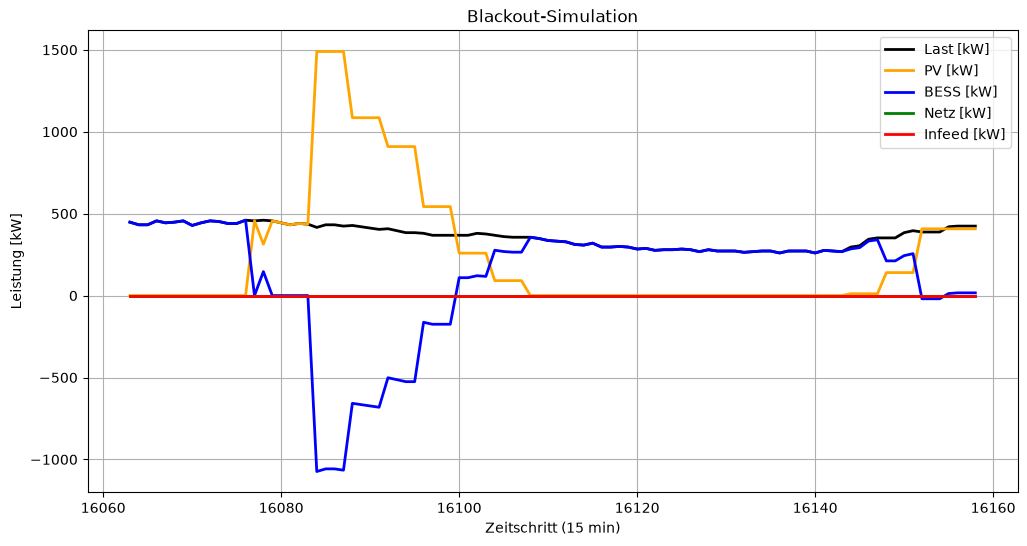

In [38]:
blackout_slice = slice(
    blackout_start,
    blackout_start + blackout_steps
)

blackout_results = pd.DataFrame({
    "Last [kW]":
        load_up.iloc[blackout_slice].to_numpy(),

    "PV [kW]":
        n_up.generators_t.p["pv"]
        .iloc[blackout_slice]
        .to_numpy(),

    "BESS [kW]":
        n_up.storage_units_t.p["Batteriespeicher"]
        .iloc[blackout_slice]
        .to_numpy(),

    "SOC [kWh]":
        n_up.storage_units_t.state_of_charge["Batteriespeicher"]
        .iloc[blackout_slice]
        .to_numpy(),

    "Netz [kW]":
        n_up.generators_t.p["grid_power"]
        .iloc[blackout_slice]
        .to_numpy(),

    "Infeed [kW]":
        -n_up.generators_t.p["infeed"]
        .iloc[blackout_slice]
        .to_numpy()

})

blackout_results.index = n_up.snapshots[blackout_slice]
blackout_results.index.name = "Zeitschritt"

display(blackout_results.round(1))

#blackout_results.to_csv("blackout_results.csv")

plt.figure(figsize=(12, 6))
plt.plot(blackout_results.index, blackout_results["Last [kW]"], label="Last [kW]", color="black", linewidth=2)
plt.plot(blackout_results.index, blackout_results["PV [kW]"], label="PV [kW]", color="orange", linewidth=2)
plt.plot(blackout_results.index, blackout_results["BESS [kW]"], label="BESS [kW]", color="blue", linewidth=2)
plt.plot(blackout_results.index, blackout_results["Netz [kW]"], label="Netz [kW]", color="green", linewidth=2)
plt.plot(blackout_results.index, blackout_results["Infeed [kW]"], label="Infeed [kW]", color="red", linewidth=2)
plt.title("Blackout-Simulation")
plt.xlabel("Zeitschritt (15 min)")
plt.ylabel("Leistung [kW]")
plt.legend()
plt.grid(True)
plt.show()

### Zusammenfassung Blackout

In [39]:
dt = 0.25

blackout_slice = slice(
    blackout_start,
    blackout_start + blackout_steps
)

# Last
energy_load = (
    load_up.iloc[blackout_slice].sum() * dt
)

# PV
energy_pv = (
    n_up.generators_t.p["pv"]
    .iloc[blackout_slice].sum() * dt
)

# BESS-Leistung
bess_power = (
    n_up.storage_units_t.p["Batteriespeicher"]
    .iloc[blackout_slice]
)

# Entladung
energy_bess_discharge = (
    bess_power.clip(lower=0).sum() * dt
)

# Ladung
energy_bess_charge = (
    bess_power.clip(upper=0).sum() * dt
)

# Netz
energy_grid = (
    n_up.generators_t.p["grid_power"]
    .iloc[blackout_slice].sum() * dt
)


print(f"Last:            {energy_load:,.0f} kWh".replace(",", "."))
print(f"PV:              {energy_pv:,.0f} kWh".replace(",", "."))
print(f"BESS Entladung:  {energy_bess_discharge:,.0f} kWh".replace(",", "."))
print(f"BESS Ladung:     {energy_bess_charge:,.0f} kWh")
print(f"Netz:            {energy_grid:,.0f} kWh")


Last:            8.686 kWh
PV:              5.987 kWh
BESS Entladung:  5.136 kWh
BESS Ladung:     -2,436 kWh
Netz:            0 kWh


### Ergebnisse des PyPSA-Netzwerks

### Vermiedene Energiekosten

In [40]:
# Auswertung PV-Erzeugung, Netzeinspeisung und Eigenverbrauch

dt_h = 0.25  # 15-Minuten-Zeitschritte = 0,25 h

# Tatsächlich von der PV-Anlage erzeugte Energie
pv_energy_kwh = n_up.generators_t.p["pv"].clip(lower=0).sum() * dt_h

# Ins öffentliche Netz eingespeiste Energie
feed_in_energy_kwh = n_up.generators_t.p["infeed"].clip(lower=0).sum() * dt_h

# PV-Eigenverbrauch
pv_self_consumption_kwh = pv_energy_kwh - feed_in_energy_kwh

# Eigenverbrauchsanteil
self_consumption_share = (
    pv_self_consumption_kwh / pv_energy_kwh
    if pv_energy_kwh > 0 else 0
)

# Einspeiseanteil
feed_in_share = (
    feed_in_energy_kwh / pv_energy_kwh
    if pv_energy_kwh > 0 else 0
)

pv_balance = pd.DataFrame({
    "Kennzahl": [
        "PV-Erzeugung",
        "Netzeinspeisung",
        "PV-Eigenverbrauch",
        "Eigenverbrauchsanteil",
        "Einspeiseanteil"
    ],
    "Wert": [
        pv_energy_kwh,
        feed_in_energy_kwh,
        pv_self_consumption_kwh,
        self_consumption_share * 100,
        feed_in_share * 100
    ],
    "Einheit": [
        "kWh",
        "kWh",
        "kWh",
        "%",
        "%"
    ]
})

display(pv_balance)

,Kennzahl,Wert,Einheit
0,PV-Erzeugung,2.500614e+06,kWh
1,Netzeinspeisung,1.287646e+06,kWh
2,PV-Eigenverbrauch,1.212968e+06,kWh
3,Eigenverbrauchsanteil,4.850680e+01,%
4,Einspeiseanteil,5.149320e+01,%


In [41]:
pv_power = n_up.generators_t.p["pv"]
load_power = n_up.loads_t.p["electrical_load"]
bess_power = n_up.storage_units_t.p["Batteriespeicher"]

# Bei StorageUnit:
# p < 0 = Laden
bess_charging = -bess_power.clip(upper=0)

check_pv = pd.DataFrame({
    "Last [kW]": load_power,
    "PV [kW]": pv_power,
    "PV minus Last [kW]": pv_power - load_power,
    "BESS-Ladung [kW]": bess_charging
})

# Nur Zeiten anzeigen, in denen PV > Last
display(
    check_pv[check_pv["PV minus Last [kW]"] > 0]
    .round(1)
)

,Last [kW],PV [kW],PV minus Last [kW],BESS-Ladung [kW]
snapshot,,,,
44,345.0,1284.9,939.9,-0.0
45,350.0,1284.9,934.9,-0.0
46,355.0,1284.9,929.9,-0.0
47,360.0,1284.9,924.9,-0.0
48,360.0,785.9,425.9,-0.0
...,...,...,...,...
34799,480.0,825.4,345.4,-0.0
34996,375.0,723.1,348.1,-0.0
34997,395.0,723.1,328.1,-0.0
